# MULTIPLE LINEAR REGRESSION

##Assignment Task:
Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.


## Dataset Description:
The dataset consists of the following variables:

Age: Age in years

KM: Accumulated Kilometers on odometer

FuelType: Fuel Type (Petrol, Diesel, CNG)

HP: Horse Power

Automatic: Automatic ( (Yes=1, No=0)

CC: Cylinder Volume in cubic centimeters

Doors: Number of doors

Weight: Weight in Kilograms

Quarterly_Tax:

Price: Offer Price in EUROs


## TASKS

### 1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre process the data to apply the MLR.

### EDA

In [7]:
#  Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
from google.colab import files
uploaded = files.upload()

Saving ToyotaCorolla - MLR.csv to ToyotaCorolla - MLR.csv


In [9]:
# Loading dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Display first few rows
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [10]:
# Checking basic info about dataset
df.info()

# Check for missing values
print("\nMissing values per column:\n", df.isnull().sum())

# Display summary statistics for all numeric variables
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB

Missing values per column:
 Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


### VISUALIZATION


In [11]:
# Setting visual style
sns.set(style="whitegrid", palette="pastel")

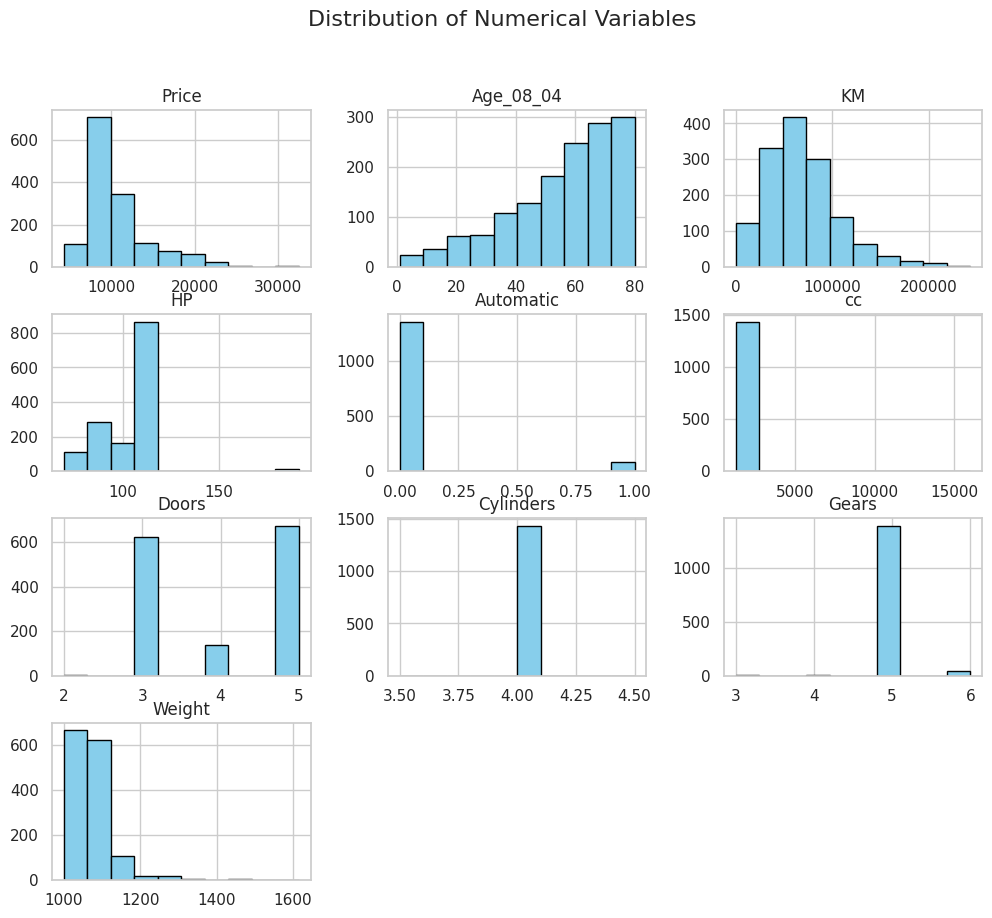

In [12]:
# 1.Histogram for numerical features
df.hist(figsize=(12,10), color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.show()

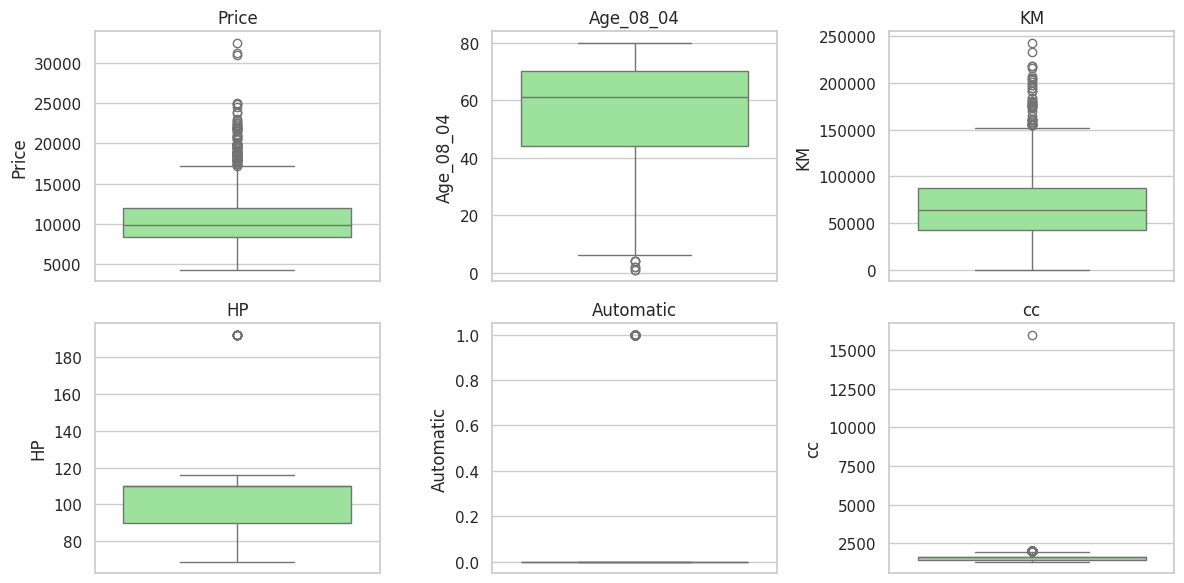

In [13]:
# 2️. Boxplots to detect outliers
plt.figure(figsize=(12,6))
for i, col in enumerate(df.select_dtypes(include='number').columns[:6]):  # first 6 columns for layout
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(col)
plt.tight_layout()
plt.show()

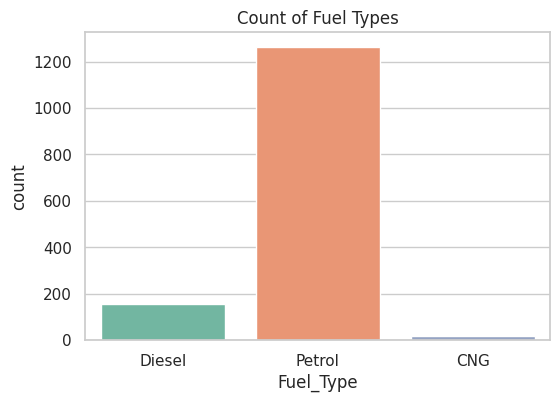

In [14]:
# 3️. Count plot for categorical feature (Fuel_Type)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Fuel_Type', hue='Fuel_Type', palette='Set2', legend=False)
plt.title("Count of Fuel Types")
plt.show()


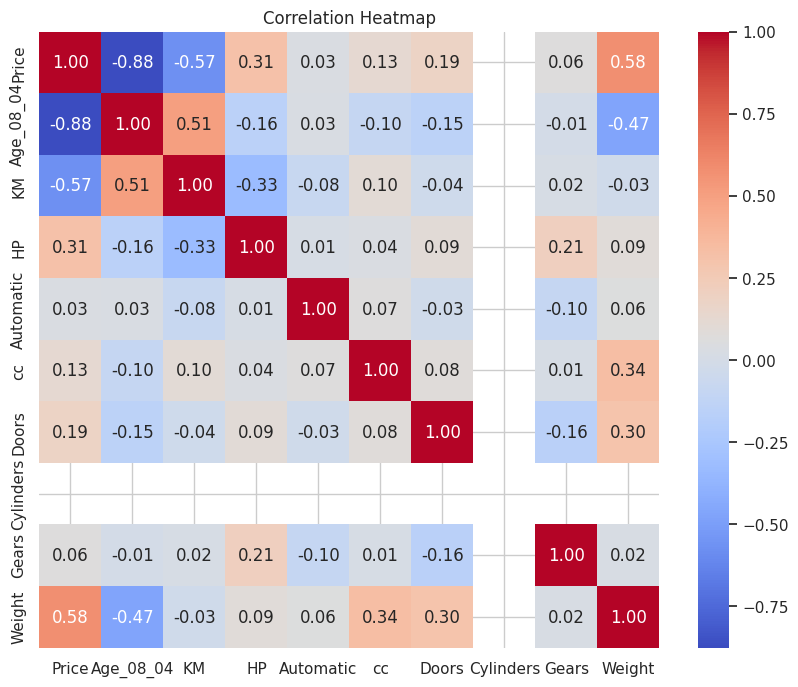

In [15]:
# 4️. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


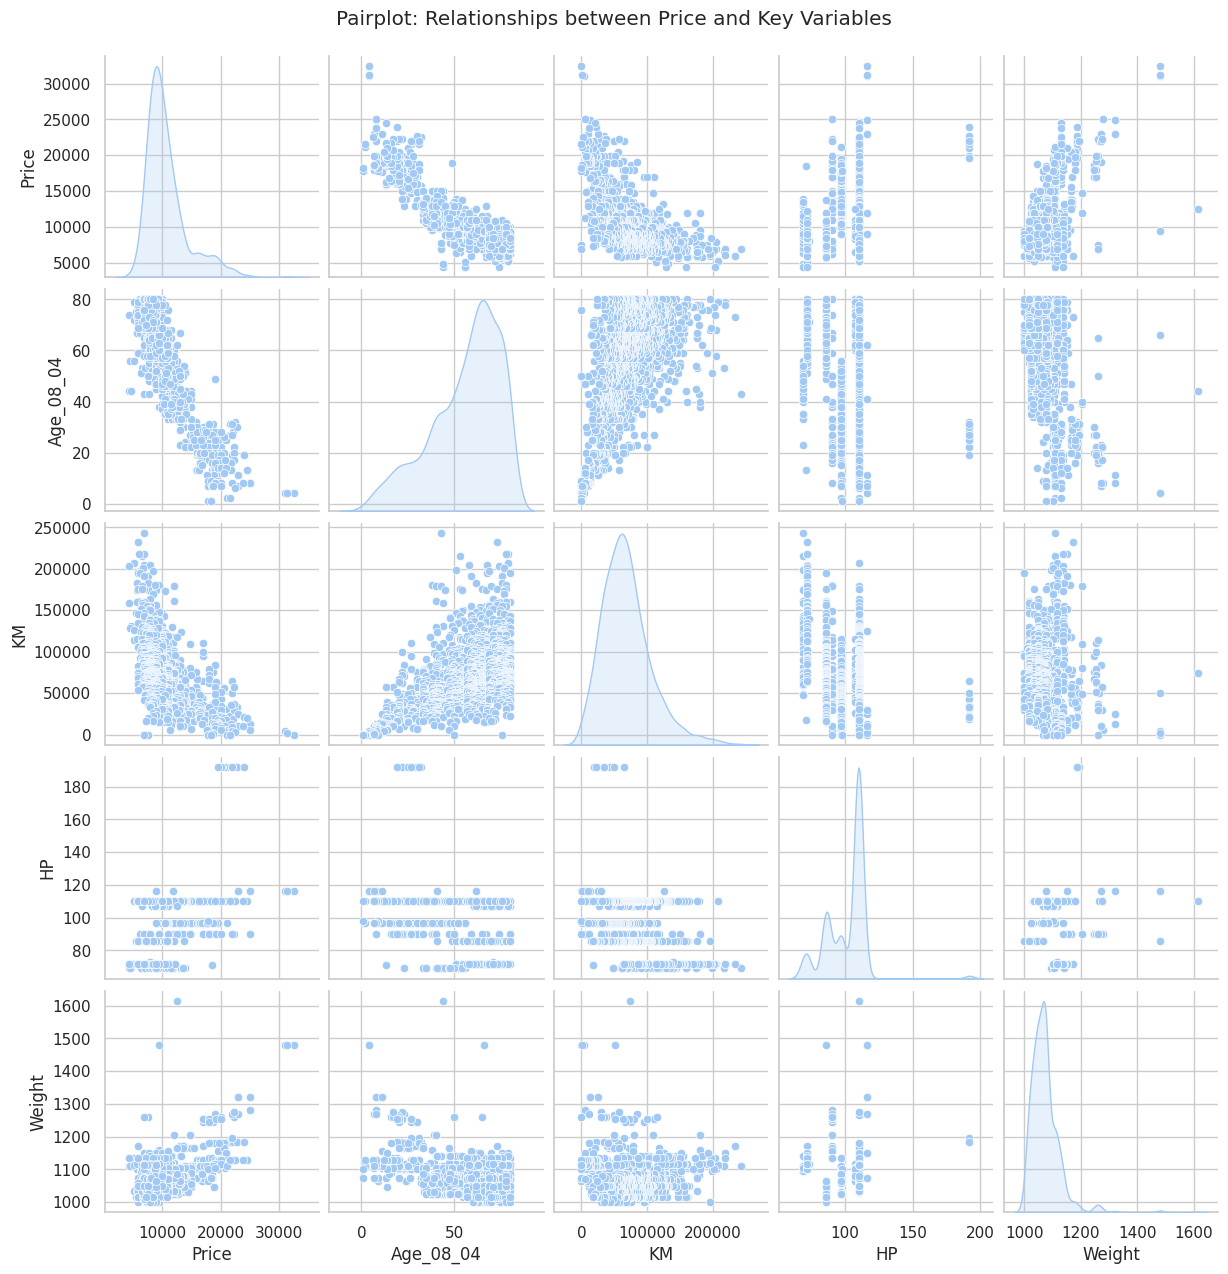

In [16]:
# 5️. Pairplot to visualize relationships between key variables and Price
selected_cols = ['Price', 'Age_08_04', 'KM', 'HP', 'Weight']
sns.pairplot(df[selected_cols], diag_kind='kde')
plt.suptitle("Pairplot: Relationships between Price and Key Variables", y=1.02)
plt.show()

## 2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
# Defining the feature variables (X) and target variable (y)

# Independent variables
X = df.drop('Price', axis=1)

# Dependent variables
y = df['Price']

In [19]:
# Split the data - 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set :", X_train.shape)
print("Testing set :", X_test.shape)

Training set : (1148, 10)
Testing set : (288, 10)


## 3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build minimum of 3 different models.

In [20]:
from sklearn.linear_model import LinearRegression


### MODEL 1 - Using All Features

In [26]:
# Separate features and target
X = df.drop(columns=['Price'])
y = df['Price']


In [31]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

LinearRegression()

In [32]:
# Display coefficients
coeff1 = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model1.coef_
})
print("Model 1 Intercept:", model1.intercept_)
display(coeff1)



Model 1 Intercept: -14255.385993565254


,Feature,Coefficient
0,Age_08_04,-1.208305e+02
1,KM,-1.623141e-02
2,HP,1.403948e+01
3,Automatic,1.488309e+02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
6,Cylinders,-1.620037e-12
7,Gears,5.516007e+02
8,Weight,2.588496e+01
9,Fuel_Type_Diesel,-6.854876e+01


### Model 2: Select only key predictors

In [33]:
from sklearn.linear_model import LinearRegression


In [34]:
features_model2 = ['Age_08_04', 'KM', 'HP', 'Weight']  # main influencing features
model2 = LinearRegression()
model2.fit(X_train[features_model2], y_train)

LinearRegression()

In [35]:
coeff2 = pd.DataFrame({
    'Feature': features_model2,
    'Coefficient': model2.coef_
})
print("Model 2 Intercept:", model2.intercept_)
display(coeff2)


Model 2 Intercept: -5304.971439931822


,Feature,Coefficient
0,Age_08_04,-120.025405
1,KM,-0.020233
2,HP,29.052170
3,Weight,19.769066


### Model 3: Add encoded Fuel Type + selected features

In [36]:
features_model3 = ['Age_08_04', 'KM', 'HP', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']
model3 = LinearRegression()
model3.fit(X_train[features_model3], y_train)

LinearRegression()

In [37]:
coeff3 = pd.DataFrame({
    'Feature': features_model3,
    'Coefficient': model3.coef_
})
print("Model 3 Intercept:", model3.intercept_)
display(coeff3)

Model 3 Intercept: -11382.1975940587


,Feature,Coefficient
0,Age_08_04,-120.665034
1,KM,-0.016237
2,HP,16.258363
3,Weight,25.257766
4,Fuel_Type_Diesel,54.190978
5,Fuel_Type_Petrol,1419.662714


## 4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

Lasso and Ridge regression are used to reduce overfitting and improve model generalization by adding a penalty to large coefficients.

Lasso (L1) tends to make some coefficients exactly zero — useful for feature selection.

Ridge (L2) shrinks coefficients smoothly but keeps all features.

In this dataset, Ridge gave a slightly better R² score and lower RMSE, showing better generalization.

Lasso removed weaker predictors, indicating which variables have less importance in predicting car price.

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [41]:
def evaluate_model(model, X_test, y_test, model_name):
    # Predictions
    y_pred = model.predict(X_test)

    # Evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n {model_name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

    return r2, mae, rmse


In [42]:
# Evaluate Model 1 (All Features)
evaluate_model(model1, X_test, y_test, "Model 1 (All Features)")



 Model 1 (All Features) Performance:
R² Score: 0.8349
Mean Absolute Error (MAE): 990.89
Root Mean Squared Error (RMSE): 1484.27


(0.8348888040611082, 990.8872739193926, np.float64(1484.2654153296514))

In [43]:
# Evaluate Model 2 (Key Predictors)
evaluate_model(model2, X_test[features_model2], y_test, "Model 2 (Key Predictors)")



 Model 2 (Key Predictors) Performance:
R² Score: 0.8506
Mean Absolute Error (MAE): 1001.20
Root Mean Squared Error (RMSE): 1411.85


(0.8506068681500583, 1001.2017466053621, np.float64(1411.85020911323))

In [44]:
# Evaluate Model 3 (Selected + Encoded Features)
evaluate_model(model3, X_test[features_model3], y_test, "Model 3 (Selected + Encoded Features)")



 Model 3 (Selected + Encoded Features) Performance:
R² Score: 0.8339
Mean Absolute Error (MAE): 1001.28
Root Mean Squared Error (RMSE): 1488.66


(0.8339087377576149, 1001.27696800871, np.float64(1488.6640456745245))

## 5.Apply Lasso and Ridge methods on the model.

In [45]:
# Import regularization models
from sklearn.linear_model import Lasso, Ridge


In [46]:
# Lasso Regression (L1 Regularization)
lasso = Lasso(alpha=0.1)   # alpha = regularization strength
lasso.fit(X_train, y_train)

# Evaluate Lasso
evaluate_model(lasso, X_test, y_test, "Lasso Regression")



 Lasso Regression Performance:
R² Score: 0.8349
Mean Absolute Error (MAE): 990.89
Root Mean Squared Error (RMSE): 1484.00


(0.8349467801805, 990.8940127223727, np.float64(1484.0048045827486))

In [47]:
# Ridge Regression (L2 Regularization)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Evaluate Ridge
evaluate_model(ridge, X_test, y_test, "Ridge Regression")



 Ridge Regression Performance:
R² Score: 0.8351
Mean Absolute Error (MAE): 990.73
Root Mean Squared Error (RMSE): 1483.15


(0.8351359377712336, 990.7338342026006, np.float64(1483.1541963778882))

In [48]:
# Compare coefficients of Lasso and Ridge
coef_comparison = pd.DataFrame({
    'Feature': X_train.columns,
    'Lasso Coefficients': lasso.coef_,
    'Ridge Coefficients': ridge.coef_,
    'Linear Regression (Base)': model1.coef_
})

print("\n Comparison of Coefficients (Shrinkage Effect):")
display(coef_comparison)



 Comparison of Coefficients (Shrinkage Effect):


,Feature,Lasso Coefficients,Ridge Coefficients,Linear Regression (Base)
0,Age_08_04,-120.827216,-120.779659,-1.208305e+02
1,KM,-0.016241,-0.016324,-1.623141e-02
2,HP,14.091453,14.141834,1.403948e+01
3,Automatic,147.287981,146.907470,1.488309e+02
4,cc,-0.030575,-0.030509,-3.037219e-02
5,Doors,-60.147193,-59.905791,-6.031097e+01
6,Cylinders,0.000000,0.000000,-1.620037e-12
7,Gears,548.658386,542.272328,5.516007e+02
8,Weight,25.868659,25.821019,2.588496e+01
9,Fuel_Type_Diesel,-64.924880,-128.813072,-6.854876e+01


# Interview Questions

### 1. What is Normalization & Standardization and how is it helpful?

- **Normalization:** Scales data to a fixed range, usually [0,1].
  - Formula: X' = (X - X_min) / (X_max - X_min)
  - Useful when data does not follow normal distribution or for distance-based models like KNN.
  
- **Standardization:** Scales data so that mean = 0 and std = 1.
  - Formula: X' = (X - μ) / σ
  - Useful when data is normally distributed, for models like Linear Regression, Logistic Regression, SVM.

**Why it’s helpful:**
- Prevents features with large values from dominating the model.
- Improves convergence of gradient descent.
- Stabilizes and improves model performance.



### 2. What techniques can be used to address multicollinearity in Multiple Linear Regression?

- **Check correlation matrix / VIF**: Detect highly correlated features.
- **Remove one of the correlated variables**: Drop redundant predictors.
- **Combine correlated features**: Use averages or PCA.
- **Regularization**: Use Ridge (L2) or Lasso (L1) regression.
- **Collect more data**: Helps stabilize coefficient estimates.
